In [7]:
import os
os.environ['PYSPARK_PYTHON']='python'

In [11]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [12]:
from pyspark.sql import SparkSession

In [13]:
spark = SparkSession.builder \
    .appName("Superstore Analysis") \
    .getOrCreate()

In [14]:
import pandas as pd

orders_pd = pd.read_excel(
    "sample-superstore.xls",
    sheet_name="Orders"
)

returns_pd = pd.read_excel(
    "sample-superstore.xls",
    sheet_name="Returns"
)

people_pd = pd.read_excel(
    "sample-superstore.xls",
    sheet_name="People"
)

In [15]:
orders = spark.createDataFrame(orders_pd)
returns = spark.createDataFrame(returns_pd)
people = spark.createDataFrame(people_pd)

In [16]:
orders.show(5)
orders.printSchema()

+------+--------------+-------------------+-------------------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+------------------+--------+--------+-------------------+
|Row ID|      Order ID|         Order Date|          Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|             Sales|Quantity|Discount|             Profit|
+------+--------------+-------------------+-------------------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+------------------+--------+--------+-------------------+
|     1|CA-2016-152156|2016-11-08 00:00:00|2016-11-11 00:00:00|  Second Class|   CG-12520|    Claire

In [17]:
orders.describe().show()

[Stage 1:>                                                        (0 + 16) / 16]

+-------+------------------+--------------+--------------+-----------+------------------+-----------+-------------+--------+-------+------------------+-------+---------------+----------+------------+--------------------+-------------------+-----------------+-------------------+------------------+
|summary|            Row ID|      Order ID|     Ship Mode|Customer ID|     Customer Name|    Segment|      Country|    City|  State|       Postal Code| Region|     Product ID|  Category|Sub-Category|        Product Name|              Sales|         Quantity|           Discount|            Profit|
+-------+------------------+--------------+--------------+-----------+------------------+-----------+-------------+--------+-------+------------------+-------+---------------+----------+------------+--------------------+-------------------+-----------------+-------------------+------------------+
|  count|              9994|          9994|          9994|       9994|              9994|       9994|     

In [22]:
# Task 4: Write a script to find the top 10 Customers by Profit

# First, register the DataFrame as a temporary view
orders.createOrReplaceTempView("orders")

# Then run your query
query4 = """
SELECT `Customer ID`, `Customer Name`, SUM(Profit) as Total_Profit
FROM orders
GROUP BY `Customer ID`, `Customer Name`
ORDER BY Total_Profit DESC
LIMIT 10
"""
result4 = spark.sql(query4)
result4.show()

[Stage 4:>                                                        (0 + 16) / 16]

+-----------+--------------------+------------------+
|Customer ID|       Customer Name|      Total_Profit|
+-----------+--------------------+------------------+
|   TC-20980|        Tamara Chand| 8981.323899999998|
|   RB-19360|        Raymond Buch| 6976.095899999999|
|   SC-20095|        Sanjit Chand| 5757.411900000001|
|   HL-15040|        Hunter Lopez|5622.4292000000005|
|   AB-10105|       Adrian Barton|5444.8054999999995|
|   TA-21385|        Tom Ashbrook| 4703.788299999999|
|   CM-12385|Christopher Martinez|3899.8903999999998|
|   KD-16495|       Keith Dawkins|         3038.6254|
|   AR-10540|         Andy Reiter|2884.6207999999997|
|   DR-12940|       Daniel Raglin|2869.0759999999996|
+-----------+--------------------+------------------+



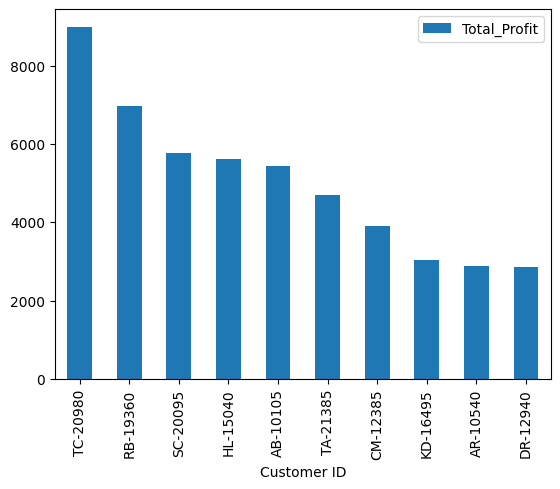

In [24]:
import matplotlib.pyplot as plt
df = result4.toPandas()
df.plot(kind = 'bar', x = "Customer ID", y = "Total_Profit")
plt.show()

In [ ]:
# Write a SQL query to find top 10 products with highlight

In [25]:
# Calculate average discount by segment

In [2]:
# write a SQL script to find the returned orders with sales and profit
## Perform inner join here